In [201]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, f1_score


In [202]:
data=pd.read_csv('titanic.csv')
data.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [203]:
#Dataset Information
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    str    
 4   Sex          418 non-null    str    
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    str    
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     str    
 11  Embarked     418 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 39.3 KB


In [204]:
#Dataset Stats
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [205]:
#Missing Values
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

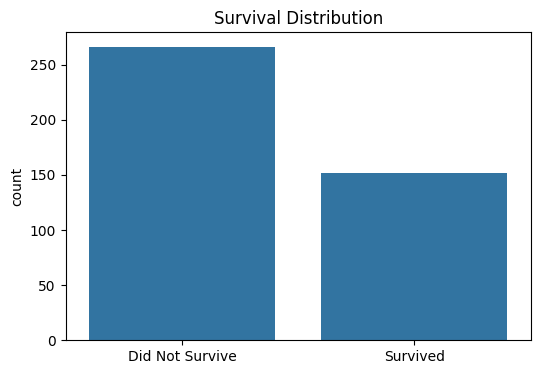

In [206]:
#EDA
#Survival Distribution
plt.figure(figsize=(6,4))
sns.countplot(x=data['Survived'])
plt.xticks([0,1],['Did Not Survive','Survived'])
plt.xlabel('')
plt.title("Survival Distribution")
plt.show()

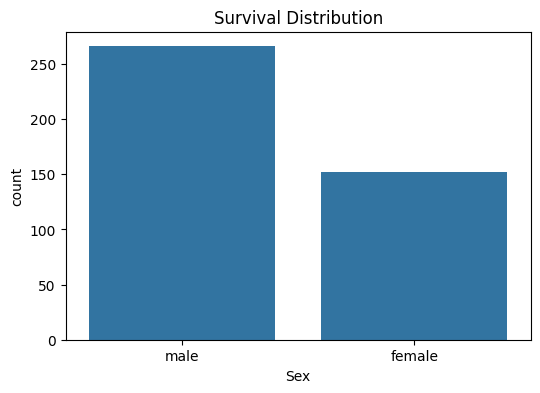

In [207]:
#Survival By Gender
plt.figure(figsize=(6,4))
sns.countplot(x='Sex',data=data)
plt.title("Survival Distribution")
plt.show()

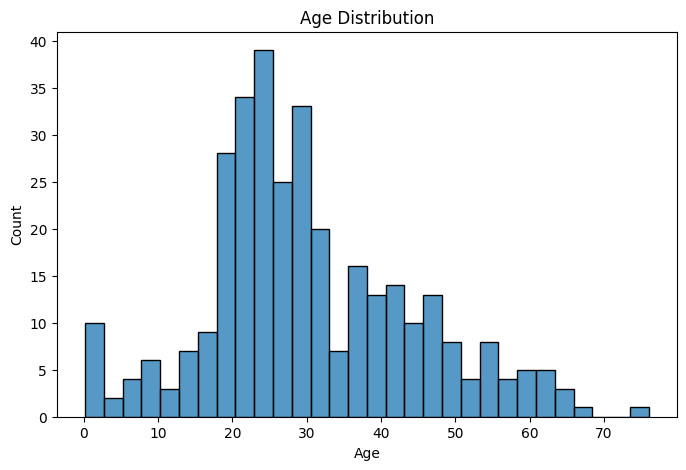

In [208]:
#Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(data['Age'],bins=30)
plt.title("Age Distribution")
plt.show()

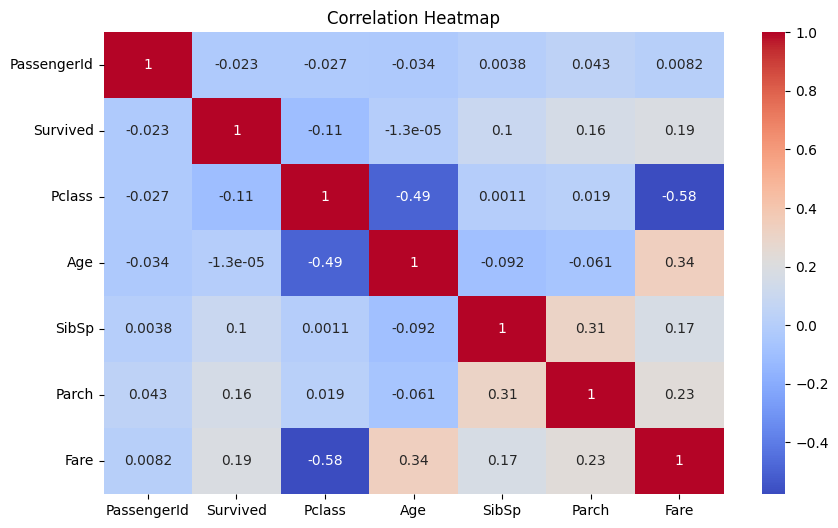

In [209]:
#Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

In [210]:
# Title Extraction
data['Title'] = data['Name'].str.extract(' ([A-Za-z]+)\.',expand=False)
print("\nTitle Distribution")
print(data['Title'].value_counts().rename_axis(None).to_string())


# Family Size
data['FamilySize'] = (data['SibSp']+data['Parch']+1)
print("\nFamily Size Distribution")
print(data['FamilySize'].value_counts().rename_axis(None).to_string())

# Cabin Presence
data['CabinPresence'] = (data['Cabin'].notnull().map({
        True: 'Cabin Available',
        False: 'No Cabin'
    })
)

print("\nCabin Presence Distribution")
print(data['CabinPresence'].value_counts().rename_axis(None).to_string())


Title Distribution
Mr        240
Miss       78
Mrs        72
Master     21
Col         2
Rev         2
Ms          1
Dr          1
Dona        1

Family Size Distribution
1     253
2      74
3      57
4      14
5       7
7       4
11      4
6       3
8       2

Cabin Presence Distribution
No Cabin           327
Cabin Available     91


In [211]:
data[
    [
        'Title',
        'FamilySize',
        'Cabin'
    ]
].head()

,Title,FamilySize,Cabin
0,Mr,1,NaN
1,Mrs,2,NaN
2,Mr,1,NaN
3,Mr,1,NaN
4,Mrs,3,NaN


In [212]:
# Handle Missing Values

# Age → Mean Imputation
data['Age'] = data[
    'Age'
].fillna(
    data['Age'].mean()
)

# Fare → Mean Imputation
data['Fare'] = data[
    'Fare'
].fillna(
    data['Fare'].mean()
)

# Cabin → Create Cabin Presence Feature
data['CabinPresence'] = (
    data['Cabin']
    .notnull()
    .map({
        True: 'Cabin Available',
        False: 'No Cabin'
    })
)

print("\nMissing Values After Imputation")
print(
    data.isnull().sum()
)

# Drop Unnecessary Columns
data.drop(columns=['PassengerId','Name','Ticket','Cabin'],inplace=True)


Missing Values After Imputation
PassengerId        0
Survived           0
Pclass             0
Name               0
Sex                0
Age                0
SibSp              0
Parch              0
Ticket             0
Fare               0
Cabin            327
Embarked           0
Title              0
FamilySize         0
CabinPresence      0
dtype: int64


In [213]:
#Encoding Categorical Variables
encoder=LabelEncoder()
categorical_cols=['Sex','Embarked','Title','CabinPresence']
for col in categorical_cols:
    data[col] = encoder.fit_transform(data[col])
print("Data After Encoding")
print(data.head())

Data After Encoding
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked  Title  \
0         0       3    1  34.5      0      0   7.8292         1      5   
1         1       3    0  47.0      1      0   7.0000         2      6   
2         0       2    1  62.0      0      0   9.6875         1      5   
3         0       3    1  27.0      0      0   8.6625         2      5   
4         1       3    0  22.0      1      1  12.2875         2      6   

   FamilySize  CabinPresence  
0           1              1  
1           2              1  
2           1              1  
3           1              1  
4           3              1  


In [214]:
#Splitting Features and Target
x=data.drop(columns=['Survived'])
y=data['Survived']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

#Feature Scaling
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

joblib.dump(scaler,'scaler.pkl')
print("Data Preprocessing Completed. Scaler saved as 'scaler.pkl'.")

Data Preprocessing Completed. Scaler saved as 'scaler.pkl'.


In [215]:
#Training Classification Models
#Logistic Regression
lr=LogisticRegression(random_state=42)
lr.fit(x_train_scaled,y_train)
lr_pred=lr.predict(x_test_scaled)

#Decision Tree
dt=DecisionTreeClassifier(random_state=42)
dt.fit(x_train_scaled,y_train)
dt_pred=dt.predict(x_test_scaled)

#Random Forest
rf=RandomForestClassifier(random_state=42)
rf.fit(x_train_scaled,y_train)
rf_pred=rf.predict(x_test_scaled)

In [216]:
#Model Evaluation
def evaluate_model(name,y_true,y_pred):
    acc=accuracy_score(y_true,y_pred)
    prec=precision_score(y_true,y_pred)
    rec=recall_score(y_true,y_pred)
    f1=f1_score(y_true,y_pred)
    conf_matrix=confusion_matrix(y_true,y_pred)
    print(f"{name}\n")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("Confusion Matrix:")
    print(conf_matrix)
    print("\n")
    return acc


In [217]:
#Final Metrics
lr_metrics = evaluate_model("Logistic Regression", y_test, lr_pred)
dt_metrics = evaluate_model("Decision Tree", y_test, dt_pred)
rf_metrics = evaluate_model("Random Forest", y_test, rf_pred)

Logistic Regression

Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
Confusion Matrix:
[[50  0]
 [ 0 34]]


Decision Tree

Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
Confusion Matrix:
[[50  0]
 [ 0 34]]


Random Forest

Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
Confusion Matrix:
[[50  0]
 [ 0 34]]




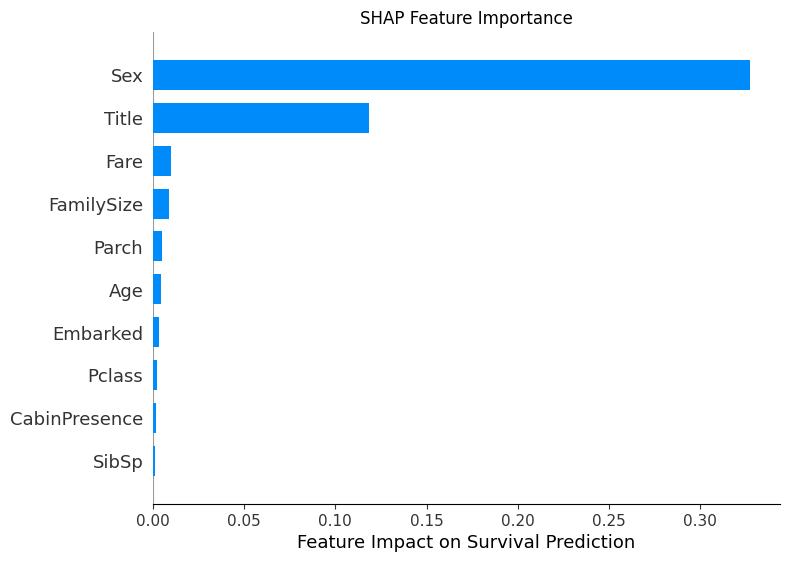

In [218]:
#Using SHAP for Model Explainability
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(x_test_scaled)
plt.figure(figsize=(10,10))
shap.summary_plot(
    shap_values[:, :, 1],
    x_test_scaled,
    feature_names=x.columns,
    plot_type="bar",
    show=False
)
plt.title("SHAP Feature Importance")
plt.xlabel("Feature Impact on Survival Prediction")
plt.show()

In [219]:
#Selecting the Best Model
models={
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf
}
accuracy_scores={
    "Logistic Regression": lr_metrics,
    "Decision Tree": dt_metrics,
    "Random Forest": rf_metrics
}
best_model_name=max(accuracy_scores, key=accuracy_scores.get)
print(f"Best Model is {best_model_name} with Accuracy {accuracy_scores[best_model_name]:.4f}")

#Saving the Best Model
joblib.dump(models[best_model_name], 'best_model.pkl')
print("Best model saved as 'best_model.pkl'.")

Best Model is Logistic Regression with Accuracy 1.0000
Best model saved as 'best_model.pkl'.


In [230]:
#Inference Example
model = joblib.load("best_model.pkl")
scaler = joblib.load("scaler.pkl")
sample = pd.DataFrame(
    [[
        1,      # PassengerClass 
        0,      # Sex (Female->0, Male->1)
        30,     # Age (Age in Years)
        0,      # Number of Siblings/Spouses Aboard
        0,      # Number of Parents/Children Aboard
        100.0,  # Ticket Fare
        2,      # Boarding Port (0->Cherbourg, 1->Queenstown, 2 -> Southampton)
        2,      # Passenger Title (0->Master, 1->Miss, 2->Mr, 3->Mrs, 4->Other)
        1,      # FamilySize
        1       # Cabin Availability (0->No Cabin, 1->Cabin Available)
]],
    columns=x.columns
)
print("\nPassenger Details\n")
for column in sample.columns:
    print(
        f"{column}: "
        f"{sample.iloc[0][column]}"
    )
sample_scaled = scaler.transform( sample)
prediction = model.predict(sample_scaled)
result = ("Survived" if prediction[0] == 1 else "Did Not Survive")
print("\nPrediction")
print(f"Passenger: {result}")


Passenger Details

Pclass: 1.0
Sex: 0.0
Age: 30.0
SibSp: 0.0
Parch: 0.0
Fare: 100.0
Embarked: 2.0
Title: 2.0
FamilySize: 1.0
CabinPresence: 1.0

Prediction
Passenger: Survived
